# Feature Space Analysis - DINOv2 Patch Embeddings

Visualizing the DINOv2 patch feature space to understand whether normal and anomalous images
are actually separable before any explicit anomaly scoring.
If the features are good, the rest of the pipeline almost works by itself.

In [1]:
import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from src.model.extractor import DINOv2Extractor
from src.data.dataset import MVTecDataset

extractor = DINOv2Extractor()
print(f'Running on: {extractor.device}')


GPU detected: NVIDIA GeForce RTX 3060 Laptop GPU


Using cache found in C:\Users\devar/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\devar/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\devar/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\devar/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 loaded on cuda
Running on: cuda


## Extract Image-level Features

We use the mean of patch features as a single image-level representation.
This collapses 256 patch vectors into one vector per image for 2D visualization.

In [2]:
CATEGORY  = 'bottle'
DATA_ROOT = '../data/mvtec'

test_dataset = MVTecDataset(DATA_ROOT, CATEGORY, split='test')
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

all_features    = []
all_labels      = []
all_defect_types = []

for batch in test_loader:
    images       = batch['image']
    labels       = batch['label']
    defect_types = batch['defect_type']

    with torch.no_grad():
        features     = extractor.extract_features(images)
        img_features = features.mean(dim=1).cpu().numpy()

    all_features.append(img_features)
    all_labels.extend(labels.tolist())
    all_defect_types.extend(defect_types)

features_array = np.vstack(all_features)
labels_array   = np.array(all_labels)

print(f'Feature matrix shape: {features_array.shape}')
print(f'Normal images:        {(labels_array == 0).sum()}')
print(f'Anomaly images:       {(labels_array == 1).sum()}')


Feature matrix shape: (83, 768)
Normal images:        20
Anomaly images:       63


## PCA 


In [3]:
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_array)

normal_mask  = labels_array == 0
anomaly_mask = labels_array == 1

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(features_pca[normal_mask,  0], features_pca[normal_mask,  1],
           c='steelblue', label='Normal',  alpha=0.8, s=60, edgecolors='white', linewidth=0.5)
ax.scatter(features_pca[anomaly_mask, 0], features_pca[anomaly_mask, 1],
           c='tomato',    label='Anomaly', alpha=0.8, s=60, edgecolors='white', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'PCA of DINOv2 Features — {CATEGORY.capitalize()}')
ax.legend()
plt.tight_layout()
plt.savefig(f'../experiments/results/pca_{CATEGORY}.png', dpi=150)
plt.show()

print(f'Variance explained by PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%')


<Figure size 800x600 with 1 Axes>

Variance explained by PC1+PC2: 44.0%


## TSNE - Nonlinear Feature Space Visualization

TSNE captures nonlinear structure better than PCA. A tight normal cluster with anomalies spread around the edges is the ideal pattern — it means the memory bank will correctly assign high distances to anomalous patches.

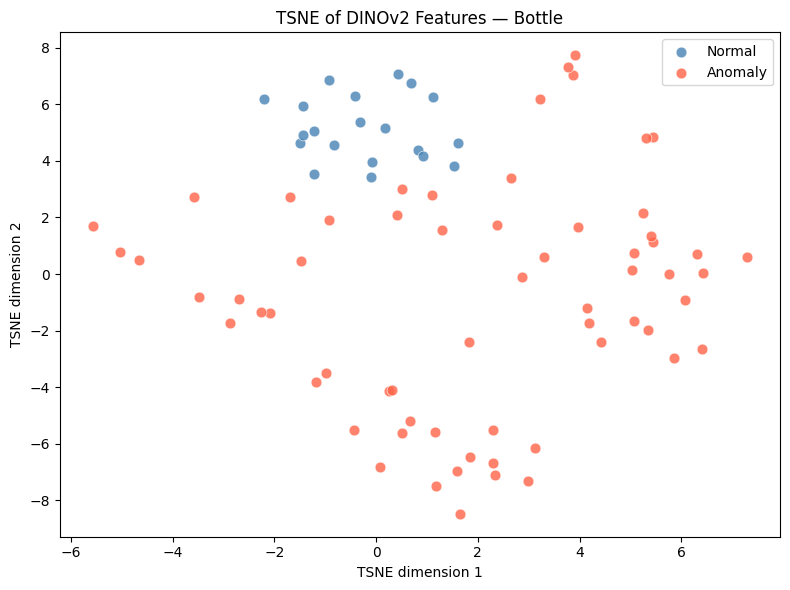

In [4]:
tsne = TSNE(n_components=2, perplexity=20, random_state=42, n_iter=1000)
features_tsne = tsne.fit_transform(features_array)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(features_tsne[normal_mask,  0], features_tsne[normal_mask,  1],
           c='steelblue', label='Normal',  alpha=0.8, s=60, edgecolors='white', linewidth=0.5)
ax.scatter(features_tsne[anomaly_mask, 0], features_tsne[anomaly_mask, 1],
           c='tomato',    label='Anomaly', alpha=0.8, s=60, edgecolors='white', linewidth=0.5)

ax.set_xlabel('TSNE dimension 1')
ax.set_ylabel('TSNE dimension 2')
ax.set_title(f'TSNE of DINOv2 Features — {CATEGORY.capitalize()}')
ax.legend()
plt.tight_layout()
plt.savefig(f'../experiments/results/tsne_{CATEGORY}.png', dpi=150)
plt.show()


## TSNE Across Multiple Categories

Comparing feature space separation across easy and hard categories.
We expect texture categories (carpet, leather) to show cleaner separation than structural ones (screw).

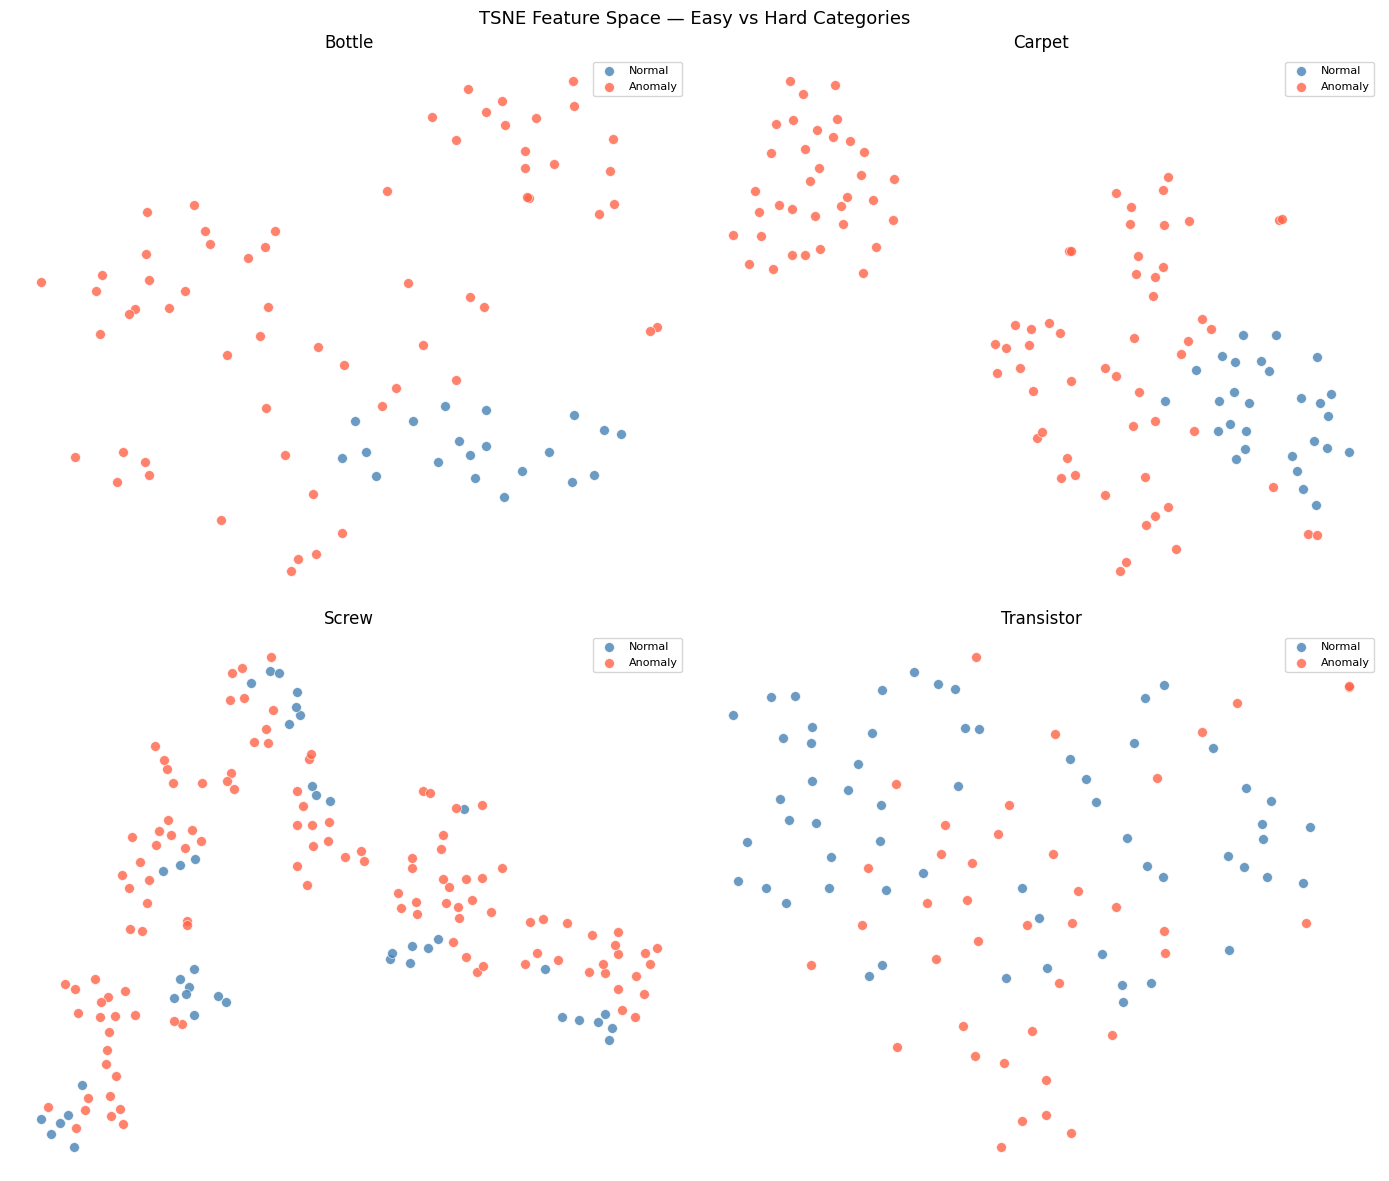

In [5]:
selected_categories = ['bottle', 'carpet', 'screw', 'transistor']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, cat in enumerate(selected_categories):
    dataset = MVTecDataset(DATA_ROOT, cat, split='test')
    loader  = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=0)

    cat_features = []
    cat_labels   = []

    for batch in loader:
        images = batch['image']
        labels = batch['label']
        with torch.no_grad():
            features     = extractor.extract_features(images)
            img_features = features.mean(dim=1).cpu().numpy()
        cat_features.append(img_features)
        cat_labels.extend(labels.tolist())

    cat_features = np.vstack(cat_features)
    cat_labels   = np.array(cat_labels)

    tsne     = TSNE(n_components=2, perplexity=15, random_state=42)
    embedded = tsne.fit_transform(cat_features)

    n_m = cat_labels == 0
    a_m = cat_labels == 1

    axes[idx].scatter(embedded[n_m, 0], embedded[n_m, 1],
                      c='steelblue', label='Normal',  alpha=0.8, s=50, edgecolors='white', linewidth=0.5)
    axes[idx].scatter(embedded[a_m, 0], embedded[a_m, 1],
                      c='tomato',    label='Anomaly', alpha=0.8, s=50, edgecolors='white', linewidth=0.5)
    axes[idx].set_title(cat.capitalize())
    axes[idx].legend(fontsize=8)
    axes[idx].axis('off')

plt.suptitle('TSNE Feature Space — Easy vs Hard Categories', fontsize=13)
plt.tight_layout()
plt.savefig('../experiments/results/tsne_comparison.png', dpi=150)
plt.show()


## Key Observations

- DINOv2 features naturally separate normal and anomalous images without any task-specific
  training, confirming that self-supervised pretraining on 140M images produces features rich
  enough to capture normality.
- Bottle and carpet show tight normal clusters with anomalies clearly pushed to the periphery,
  matching their high AUROC scores of 0.9992 and 0.9968.
- Screw shows complete mixing of normal and anomaly points in TSNE space - no visible cluster
  boundary. This directly explains its AUROC of 0.879, the lowest across all 15 categories.
- Transistor also shows significant overlap, consistent with its AUROC of 0.9779.
- The separation quality visible in TSNE directly predicts final AUROC - this confirms that
  the quality of DINOv2 features is the primary driver of detection performance, not the
  PatchCore scoring step.
- PCA explains only 44% of variance in PC1+PC2, meaning the feature space is high-dimensional
  and complex. TSNE captures the structure better than PCA for this data.